# Results Parser

In [71]:
import pandas
import matplotlib.pyplot as plt

## Collating all stages results into 1 table

In [100]:
FILE_PREFIX = "hmm-hard-em-upos_2"
NUM_STAGES = 25

# Get all results
all_results = []
for i in range(0, NUM_STAGES):
    file_path = f"./results/{FILE_PREFIX}/{FILE_PREFIX}.{i}.csv"
    try:
        df = pandas.read_csv(file_path)
        df["epoch"] = i+1
        all_results.append(df)
    except FileNotFoundError:
        print(f"Stopping: Results for stage {i+1} not found")
        break

# Save all resuluts
all_results = pandas.concat(all_results)
all_results.to_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}-all-stages.csv", index=False)

all_results.head()

Stopping: Results for stage 22 not found


,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score,epoch
0,-,5.410673,0.899548,0.085482,0.121778,0.100452,1.000000,1
0,0,-,5.395298,0.897445,0.087228,0.124417,0.102555,2
0,0,-,5.372289,0.895232,0.088949,0.127430,0.104768,3
0,0,-,5.340149,0.891265,0.092173,0.132552,0.108735,4
0,0,-,5.320384,0.888942,0.094039,0.135598,0.111058,5


## Load actual full dataset stats

In [27]:
FILE_PREFIX = "hmm-sem-upos"

whole_dataset_results = pandas.read_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}.csv")
display(whole_dataset_results)

,id,sentence,VI,normalized-VI,homogeneity,completeness,V-score
0,0,-,3.979159,0.533721,0.491827,0.443254,0.466279


## Draw Graphs

### HMM sEM UPOS: alpha 1 | whole dataset | 20 epochs
107 mins train and test

In [ ]:
FILE_PREFIX = "hmm-sem-upos"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pandas.read_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM sEM UPOS: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

### HMM sEM UPOS: alpha 1 | whole dataset | 20 epochs
xxx mins train and test

In [ ]:
FILE_PREFIX = "hmm-sem-xpos"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pandas.read_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM sEM XPOS: Epochs vs {FIELD}")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()

### HMM Hard EM UPOS

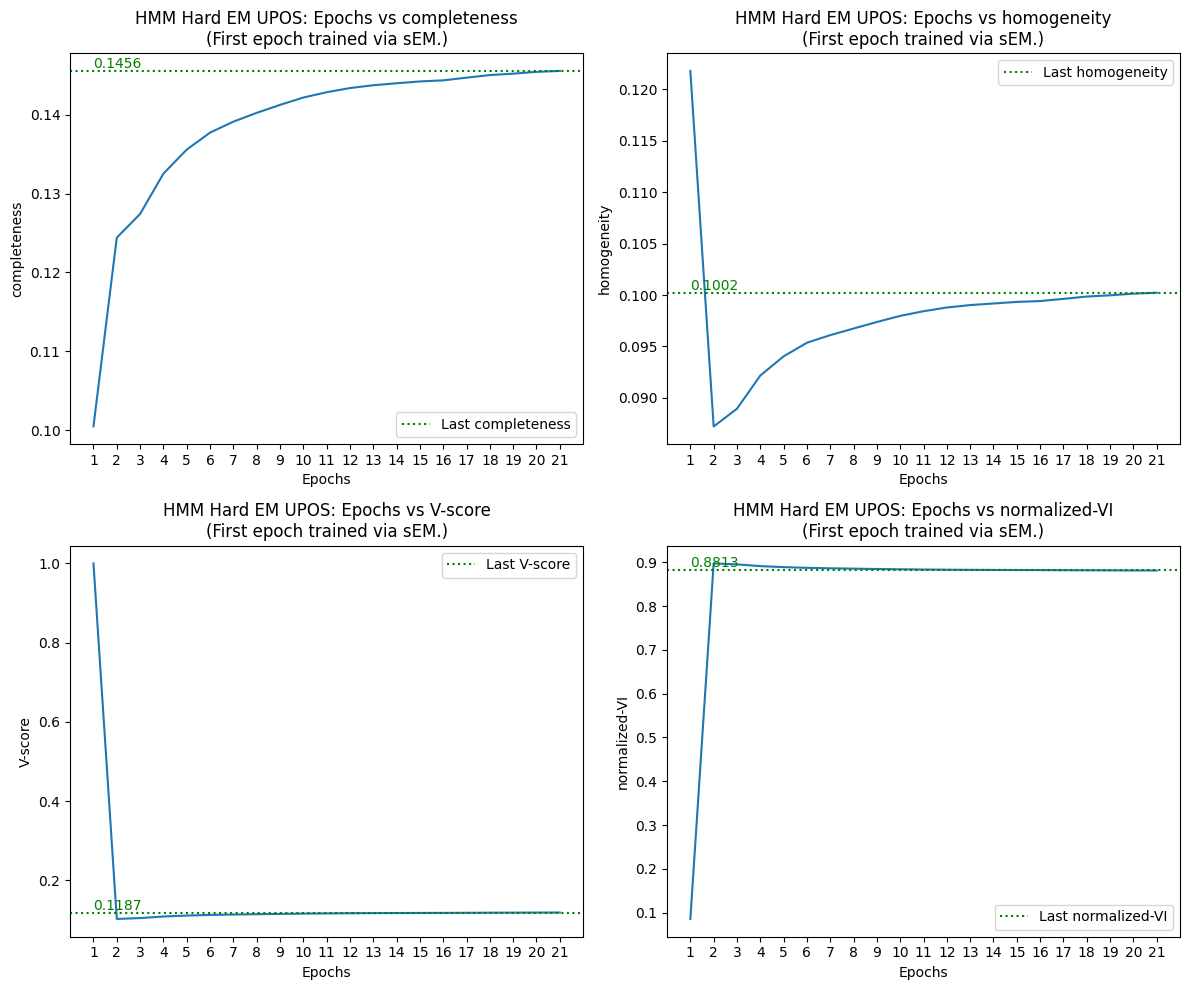

In [105]:
FILE_PREFIX = "hmm-hard-em-upos_2"
FIELDS = ["completeness", "homogeneity", "V-score", "normalized-VI"]

all_results = pandas.read_csv(f"./results/{FILE_PREFIX}/{FILE_PREFIX}-all-stages.csv")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, FIELD in enumerate(FIELDS):

    ax = axes[i]
    
    last_value = all_results[FIELD].iloc[-1]

    ax.plot(all_results["epoch"], all_results[FIELD])
    ax.set_xticks(all_results["epoch"].unique())

    ax.axhline(
        y=last_value,
        color='g',
        linestyle=':',
        label=f'Last {FIELD}'
    )
    
    ax.text(
        all_results["epoch"].min(), last_value, 
        f"{last_value:.4f}", 
        va='bottom', ha='left', color='g'
    )

    ax.set_title(f"HMM Hard EM UPOS: Epochs vs {FIELD}\n(First epoch trained via sEM.)")
    ax.set_xlabel("Epochs")
    ax.set_ylabel(f"{FIELD}")
    ax.legend()

plt.tight_layout()
plt.show()